In [43]:
import numpy as np
from scipy.interpolate import interp1d
import time
import redshifts
from math import lgamma
import loginterp
import common as c
import copy
import scipy
from scipy.linalg import cholesky
from scipy import linalg
import healpy as hp
import config as conf
import estim
from estim import estimator
import pyfftlog 
import importlib
import redshifts
import spectra
import matplotlib.pyplot as plt
from math import pi
import config as conf
import my_remote_spectra as remote_spectra
import density_field_library as DFL
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [44]:
def plot_cross_section(fft3dmap):
    fig, _ = plt.subplots(3, 1,figsize=(6*1,4.5*3))
    
    ax1 = plt.subplot(3,1,1)
    fig.colorbar(ax1.imshow(fft3dmap[0,:,:], origin='lower'), ax=ax1)
    ax1.set_xlabel('y')
    ax1.set_ylabel('z')

    ax2 = plt.subplot(3,1,2)
    # ax2.imshow(psi_i[0,:,:].T)
    fig.colorbar(ax2.imshow(fft3dmap[:,0,:].T, origin='lower'), ax=ax2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('z')

    ax3 = plt.subplot(3,1,3)
    # ax3.imshow(psi_i[:,10,:])
    fig.colorbar(ax3.imshow(fft3dmap[:,:,0], origin='lower'), ax=ax3)
    ax3.set_xlabel('y')
    ax3.set_ylabel('x')

def RDF_recNoise(lmax, Cltaug, ClTT, Clgg):
    ls = np.arange(lmax+1)
    ls = np.tile(ls[:, np.newaxis], (1, Cltaug.shape[-1]))
    
    return 1/np.sum((2*ls[2:,]+1)/(4*np.pi)*Cltaug[2:,]**2/(ClTT[2:,]*Clgg[2:,]), axis=0)

In [45]:
importlib.reload(conf)
importlib.reload(estim)
zb = redshifts.binning(conf_module = conf) 
# test vmap simulation
data_lmax = 4000
lmax = 4000

estimator = estimator(data_lmax, conf)
ls = np.arange(lmax+1)

<module 'config' from '/home/hongbo/tools/ReCCO/code/config.py'>

<module 'estim' from '/home/hongbo/tools/ReCCO/code/estim.py'>

Default lss = 'g' . Modify with set_lss method.
Default N_fine_modes = 4. Modify with set_Nfine method.


In [4]:
# print(Cls.shape)
print(zb.zbins_z)
print(zb.zbins_zcentral)
print(zb.zbins_chi)
print(zb.deltachi)

[0.4        0.47005369 0.5431901  0.61972371 0.7       ]
[0.43466005 0.50621758 0.58101143 0.65937111]
[1591.9856773  1835.47267685 2078.95967641 2322.44667597 2565.93367553]
243.4869995586555


In [5]:
# CLvrvr = estimator.load_theory_Cl('vr', 'vr')
estimator.set_theory_Cls(add_ksz = False, add_ml=False)

In [6]:
Clgg = estimator.Cls['lss-lss'] # with shot noise (also maybe calibration noise)
Cltaudg = estimator.Cls['taud-lss']
Cltaug = Cltaudg*zb.deltachi
ClTT = estimator.Cls['T-T'] # with noise
Clvrvr = estimator.Cls['vr-vr']
ClN_RDF = RDF_recNoise(lmax, Cltaug.diagonal(axis1=1, axis2=2), ClTT.diagonal(axis1=1, axis2=2), Clgg.diagonal(axis1=1, axis2=2))

In [7]:
beam = conf.beamArcmin_T*np.pi/180./60.
dT = conf.noiseTuKArcmin_T*np.pi/180./60./conf.T_CMB

In [42]:
ClTT.shape

(4001, 1, 1)

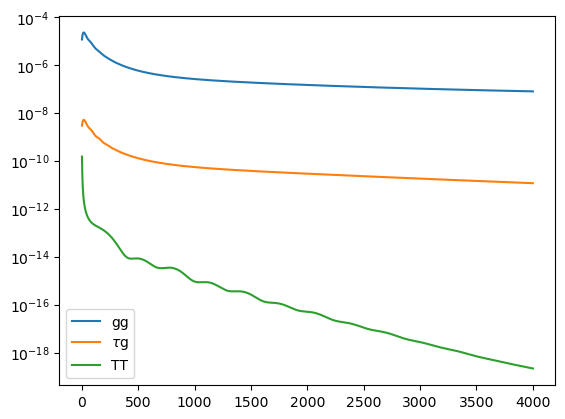

In [8]:
bin_num = 0
# plt.plot(L, CLgg[:, bin_num, bin_num], label='gg')
plt.plot(ls[2:], Clgg[:, bin_num, bin_num][2:], label='gg')
plt.plot(ls[2:], Cltaug[:, bin_num, bin_num][2:], label=r'$\tau$g')
plt.plot(ls[2:], ClTT[:, 0, 0][2:], label=r'TT')
plt.yscale('log')
plt.legend()

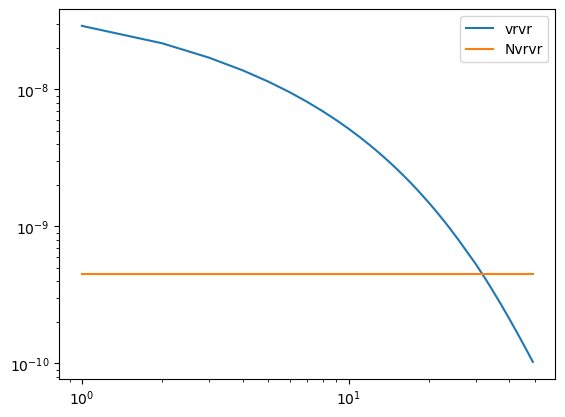

In [40]:
bin_num = 2
llow, lhigh = 1, 50
# plt.plot(L, CLgg[:, bin_num, bin_num], label='gg')
plt.plot(ls[llow:lhigh], Clvrvr[:, bin_num, bin_num][llow:lhigh], label='vrvr')
plt.plot(ls[llow:lhigh], (np.ones_like(ls)*ClN_RDF[bin_num])[llow:lhigh], label='Nvrvr')
plt.xscale('log')
plt.yscale('log')
plt.legend()

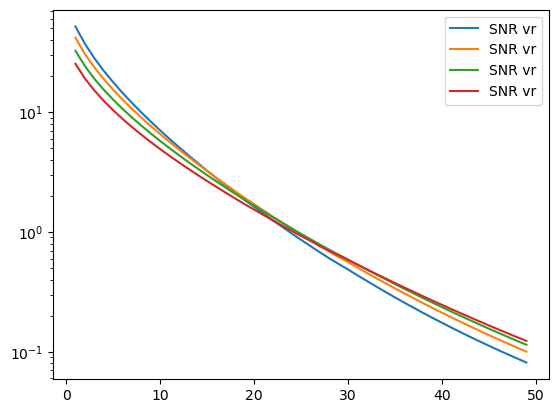

In [19]:
llow, lhigh = 1, 50
# plt.plot(L, CLgg[:, bin_num, bin_num], label='gg')
for bin_num in [0, 1, 2, 3]:
    SNR = np.sqrt(0.5/2*(Clvrvr[:, bin_num, bin_num]/(np.ones_like(ls)*ClN_RDF[bin_num]))**2)
    plt.plot(ls[llow:lhigh], SNR[llow:lhigh], label='SNR vr')
plt.yscale('log')
plt.legend()

In [26]:
L_plot_max = 50
L = estimator.load_L()
L_plot = L[np.where(L<L_plot_max)]
print(L_plot)
for bin_i in range(conf.N_bins):
    plt.plot(L_plot, L_plot**2*(CLvrvr[:, bin_i, bin_i])[np.where(L<L_plot_max)], label=r'$bin=%s$' %(bin_i+1))
plt.legend()
plt.ylim((-1e-7, 7e-7))
plt.axhline(y=-0, c='k', linestyle='--')
# plt.yscale('log')

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 20 21 23 24 26 28
 30 32 34 37 40 43 46 49]


NameError: name 'CLvrvr' is not defined

In [12]:
print('Generating vmap and vlm')
nside = 30
maps, alms = estimator.get_maps_and_alms(['vr', 'taud', 'g', 'vt', 'ml'], nside, lmax)
vmaps, taudmaps, lssmaps, vtmaps, mlpmaps = maps[0], maps[1], maps[2], maps[3], maps[4]
vlms, taudlms, lsslms, vtlms, mlplms = alms[0], alms[1], alms[2], alms[3], alms[4]

Generating vmap and vlm
cholesky
formatting covmat
generating realization


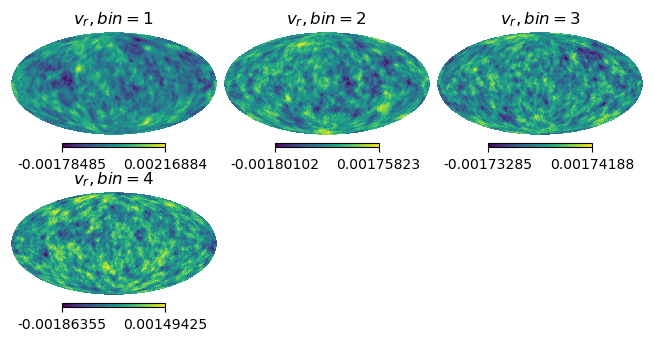

In [17]:
for bin_i in range(conf.N_bins):
    subnum = '33'+r'%s' %(bin_i+1)
    hp.mollview(vmaps[bin_i], sub=int(subnum), title=r'$v_{r}, bin=%s$' %(bin_i+1))

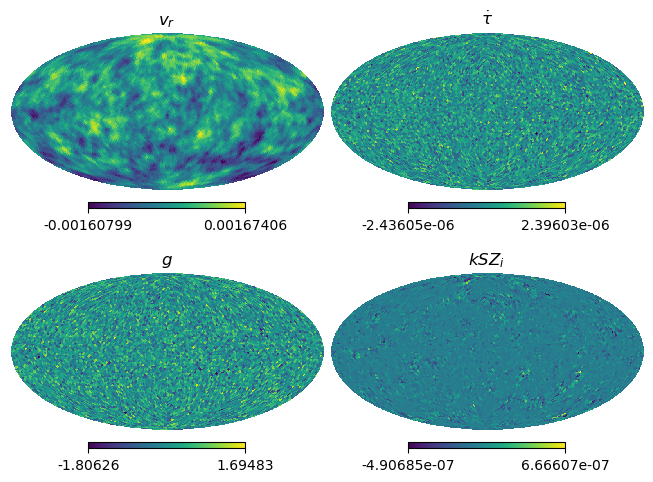

In [120]:
# test kSZ map making
bin_i = 0
kszmap = vmaps[bin_i]*taudmaps[bin_i]*zb.deltachi
if 1:
    hp.mollview(vmaps[bin_i], sub=221, title=r'$v_{r}$') 
    hp.mollview(taudmaps[bin_i], sub=222, title=r'$\dot{\tau}$') 
    hp.mollview(lssmaps[bin_i], sub=223, title=r'$g$') 
    hp.mollview(kszmap, sub=224, title=r'$kSZ_{i}$')     

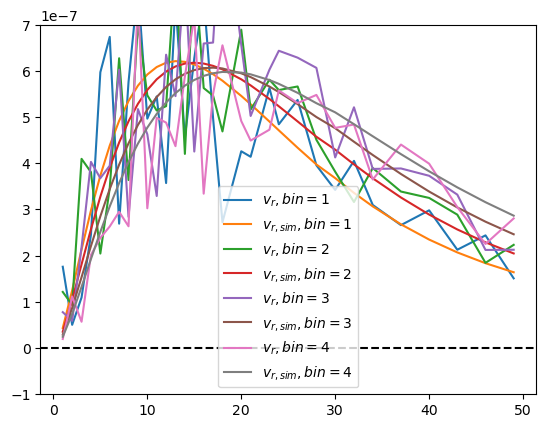

In [150]:
Clvrvr_sim = []
for bin_i in range(conf.N_bins):
    Clvrvr_sim.append(hp.alm2cl(vlms[bin_i]))    
if 1:
    for bin_i in range(conf.N_bins):
        plt.plot(L_plot, L_plot**2*(Clvrvr_sim[bin_i])[L_plot], label=r'$v_{r}, bin=%s$' %(bin_i+1))
        plt.plot(L_plot, L_plot**2*(CLvrvr[:, bin_i, bin_i])[np.where(L<L_plot_max)], label=r'$v_{r,sim}, bin=%s$' %(bin_i+1))
        
    # plt.yscale('log')
    plt.legend()
    plt.ylim((-1e-7, 7e-7))  
    plt.axhline(y=-0, c='k', linestyle='--')

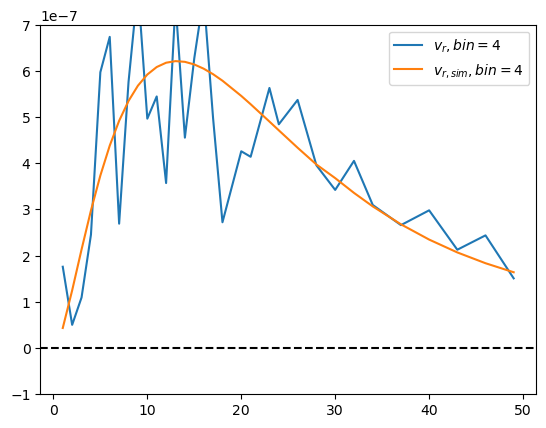

In [151]:
bin_test = 0

plt.plot(L_plot, L_plot**2*(Clvrvr_sim[bin_test])[L_plot], label=r'$v_{r}, bin=%s$' %(bin_i+1))
plt.plot(L_plot, L_plot**2*(CLvrvr[:, bin_test, bin_test])[np.where(L<L_plot_max)], label=r'$v_{r,sim}, bin=%s$' %(bin_i+1))
plt.legend()
plt.ylim((-1e-7, 7e-7))  
plt.axhline(y=-0, c='k', linestyle='--')

In [20]:
def get_Clvv_eff(Ls, ks, Pk, ze, Omega_b, Omega_c, w, wa, Omega_K, h, component='localDopp'):
    Clvv_eff = []
    if component == 'localDopp':
        transfer_ksz_k_L = remote_spectra.Transfer_ksz_localDopp_redshift(ks, Ls, ze, Omega_b, Omega_c, w, wa, Omega_K, h)
    if component == 'total':
        transfer_ksz_k_L = remote_spectra.Transfer_ksz_redshift(ks, Ls, ze, Omega_b, Omega_c, w, wa, Omega_K, h)
    
    for L_num in range(len(Ls)):                                                                         
        Clvv_eff.append(np.trapz(ks**2*Pk*transfer_ksz_k_L[:, L_num]**2, ks)/(2*pi)**3)
    return np.array(Clvv_eff)

In [27]:
def get_Clqq_eff(Ls, ks, Pk, ze, Omega_b, Omega_c, w, wa, Omega_K, h):
    Clqq_eff = []
    transfer_psz_k_L = remote_spectra.Transfer_psz_redshift(ks, Ls, ze, Omega_b, Omega_c, w, wa, Omega_K, h)
    
    for L_num in range(len(Ls)):                                                                         
        Clqq_eff.append(np.trapz(ks**2*Pk*transfer_psz_k_L[:, L_num]**2, ks)/(2*pi)**3)
    return np.array(Clqq_eff)

In [22]:
# Calculate theory Clvrvr on light cone slice without width
import config as conf
import kszpsz_config as config
ze = 0.7
As= conf.As
ns = conf.ns
# k_sampling = remote_spectra.k_sampling()
k_sampling = np.linspace(1e-5, 1e-2, 20000)
Pk_sampling = remote_spectra.Ppsi(k_sampling, As, ns)

In [36]:
Ls = np.arange(2, 30, 2)
Clvv_eff_localDopp_theory = get_Clvv_eff(Ls, k_sampling, Pk_sampling, ze, config.Omega_b, \
                               config.Omega_c, config.w, config.wa, config.Omega_K, config.h, component='localDopp')
Clvv_eff_total_theory = get_Clvv_eff(Ls, k_sampling, Pk_sampling, ze, config.Omega_b, \
                               config.Omega_c, config.w, config.wa, config.Omega_K, config.h, component='total')

In [37]:
remote_spectra.Transfer_psz_redshift(k_sampling, Ls, ze, config.Omega_b, \
                               config.Omega_c, config.w, config.wa, config.Omega_K, config.h)

IndexError: index 14 is out of bounds for axis 1 with size 14

In [32]:
Clqq_theory = get_Clqq_eff(Ls, k_sampling, Pk_sampling, ze, config.Omega_b, \
                               config.Omega_c, config.w, config.wa, config.Omega_K, config.h)

IndexError: index 24 is out of bounds for axis 1 with size 24

/home/hongbo/tools/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/hongbo/tools/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


NameError: name 'L_plot' is not defined

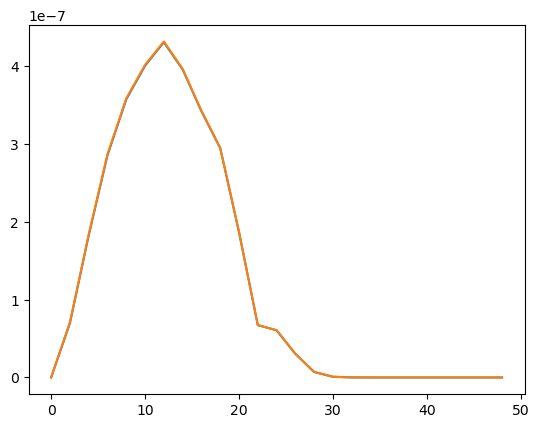

In [24]:
plt.plot(Ls, Ls**2*Clvv_eff_localDopp_theory)
plt.plot(Ls, Ls**2*Clvv_eff_total_theory)
plt.plot(L_plot, L_plot**2*(Clvrvr_sim[bin_test])[L_plot], label=r'$v_{r}, bin=%s$' %(bin_i+1))
plt.plot(L_plot, L_plot**2*(CLvrvr[:, bin_test, bin_test])[np.where(L<L_plot_max)], label=r'$v_{r,sim}, bin=%s$' %(bin_i+1))
plt.legend()
# plt.ylim((-1e-7, 7e-7))  
plt.axhline(y=-0, c='k', linestyle='--')

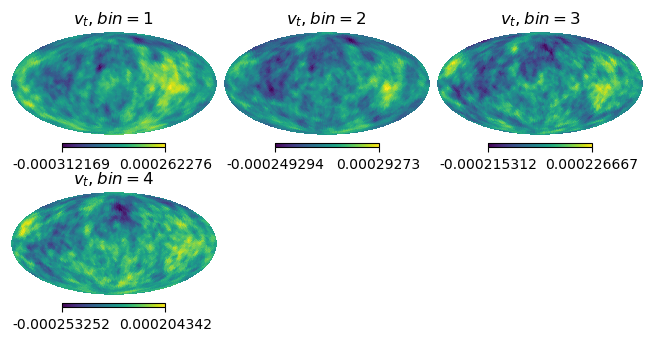

In [297]:
for bin_i in range(conf.N_bins):
    subnum = '33'+r'%s' %(bin_i+1)
    hp.mollview(vtmaps[bin_i], sub=int(subnum), title=r'$v_{t}, bin=%s$' %(bin_i+1))

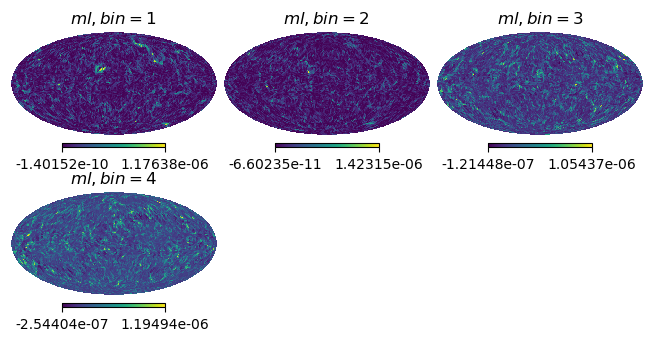

In [304]:
# simulate some moving lens
for bin_i in range(conf.N_bins):
    subnum = '33'+r'%s' %(bin_i+1)
    map_ml_i, ml_d_theta, ml_d_phi = hp.sphtfunc.alm2map_der1(mlplms[bin_i], nside)
    map_vt_i, vt_d_theta, vt_d_phi = hp.sphtfunc.alm2map_der1(vtlms[bin_i], nside)
    mlmap = (ml_d_theta * vt_d_theta + ml_d_phi * vt_d_phi)*zb.deltachi
    hp.mollview(mlmap, sub=int(subnum), title=r'$ml, bin=%s$' %(bin_i+1))